In [1]:
import numpy as np
import pandas as pd

In [2]:
df= pd.read_csv("clean_data.csv")
df.head()

,nhom_bds_lon,nhom_bds,loai_bds,quan_huyen,ten_duong,dia_chi,gia(ty),trieu/m2,dien_tich(m2),ngang (m),doc (m),huong,phap_ly,so_tang,so_phong_ngu,so_wc,tieu_de,nguon
0,Nhà,Biệt thự/Nhà liền kề,"Biệt thự, nhà liền kề",Thành phố Quy Nhơn,Cao Văn Lầu,Đường cao văn lầu,8.0,60.150376,133.0,7.0,19.0,Đông,Đang cập nhật,3,6,4,Biệt thự mặt tiền Cao Văn Lầu – quy nhơn nam g...,https://alonhadat.com.vn/-biet-thu-mat-tien-ca...
1,Nhà,Biệt thự/Nhà liền kề,"Biệt thự, nhà liền kề",Thành phố Quy Nhơn,Không rõ,Đường rộng thoáng....... << xem chi tiết >> 28...,14.2,65.740741,216.0,10.0,21.6,Tây,Đang cập nhật,4,4,4,Bán 2 căn biệt thự 4 tầng khu đại phú gia – đẳ...,https://alonhadat.com.vn/-ban-2-can-biet-thu-4...
2,Nhà,Căn hộ chung cư,Căn hộ chung cư,Thành phố Quy Nhơn,Lê Đức Thọ,Đường Lê Đức Thọ - để lại full nội thất - 3 ph...,2.9,33.720930,86.0,8.0,11.0,Tây,Đang cập nhật,18,3,2,Bán nhanh căn hộ 3pn phú tài residences giá tốt,https://alonhadat.com.vn/ban-nhanh-can-ho-3pn-...
3,Đất,Đất nền/Đất ở,Đất thổ cư/đất ở,Huyện Phù Cát,Tỉnh lộ 639,Đường Tỉnh Lộ 639,2.3,11.979167,192.0,8.0,25.0,Chưa xác định,Đang cập nhật,0,0,0,Bán lô góc tân thanh - cát hải,https://alonhadat.com.vn/ban-lo-goc-tan-thanh-...
4,Nhà,Căn hộ chung cư,Căn hộ chung cư,Thành phố Quy Nhơn,Nguyễn Tất Thành,Đường Nguyễn Tất Thành,2.3,35.384615,65.0,0.0,0.0,Chưa xác định,Đang cập nhật,12,2,2,Kẹt vốn bán cắt lỗ căn hộ grand center quy nhơ...,https://alonhadat.com.vn/ket-von-ban-cat-lo-ca...


Vấn đề của ten_duong: Dữ liệu có tới 138 tên đường khác nhau tại Bình Định. Nếu đưa ten_duong vào nhóm CAT_COLS để chạy OneHotEncoder, bộ mã hóa sẽ tự động sinh ra 138 cột mới (toàn số 0 và 1).
Hậu quả: 
- Số lượng cột tăng đột biến làm ma trận dữ liệu bị thưa (Sparse Matrix), khiến mô hình tuyến tính như Ridge bị nhiễu, còn mô hình cây như Random Forest sẽ bị phân mảnh và Overfitting nặng (học vẹt tên đường).
- Tập Test có thể xuất hiện những con đường mới toanh mà tập Train chưa từng thấy, làm mô hình bị lỗi khi dự báo.

Thế nên thay vì dùng trực tiếp tên đường ta sẽ phân nhóm thô (phan_khu & nhom_tuyen_duong): Bạn gom 138 con đường thành 4-5 phân khu chiến lược (Quy Nhơn Mới, Đông, Nam, Bắc) và đặc trưng tuyến đường (Trục huyết mạch, Ven biển, Nội bộ...). Việc này giảm từ 138 danh mục xuống còn 5 danh mục  →  Mô hình dễ học hơn hẳn.

In [3]:
# Phân loại các con đường vào các phân khu chiến lược khác nhau tại Bình Định 
# 1. Định nghĩa danh sách đường cho từng phân khu theo chiến lược của bạn
quy_nhon_moi = [
    # Khu vực Hải Cảng, Trần Phú, Trung tâm Hành chính - Dịch vụ cũ & mới
    'Nguyễn Huệ', 'Xuân Diệu', 'Trần Hưng Đạo', 'Tăng Bạt Hổ', 'Lê Hồng Phong',
    'Ngô Mây', 'Nguyễn Thái Học', 'Hai Bà Trưng', 'Trần Phú', 'Lê Lợi', 'Vũ Bảo',
    'Đô Đốc Bảo', 'Biên Cương', 'Phan Bội Châu', 'Hùng Vương', 'Trần Cao Vân',
    'Phan Đình Phùng', 'Bạch Đằng', 'Diên Hồng', 'Mai Xuân Thưởng', 'Phạm Hồng Thái',
    'Chu Văn An', 'Nguyễn Tất Thành', 'Lê Đức Thọ', 'Tô Hiến Thành', 'Nguyễn Lữ',
    'Hoàng Văn Thụ', 'Đinh Bộ Lĩnh', 'Thành Thái', 'Nguyễn Trãi', 'Trần Thị Kỷ',
    'Cần Vương', 'Hải Thượng Lãn Ông', 'Hàm Nghi', 'Bà Huyện Thanh Quan', 'Tháp Đôi',
    'Đống Đa', 'Phó Đức Chính', 'Nguyễn Khuyến', 'Lê Duẩn', 'Lê Bá Trinh'
]

quy_nhon_dong = [
    # Khu vực Nhơn Bình, Nhơn Lý, Đầm Thị Nại, Bán đảo Phương Mai (Sinh thái, Du lịch)
    'Võ Nguyên Giáp', 'Điện Biên Phủ', 'Nguyễn Diêu', 'Huỳnh Tịch Của', 'Ngô Đức Đệ',
    'La Văn Tiến', 'Đặng Thùy Trâm', 'Phan Thúc Trực', 'Lê Hoàn', 'Lý Thái Tổ',
    'Võ Mười', 'Nguyễn Huy Tưởng', 'Lê Văn Thủ', 'Đào Doãn Địch', 'Huỳnh Thúc Kháng',
    'Hoàng Minh Giám', 'Trần Văn Ơn', 'Hoa Lư', 'Trần Anh Tông', 'Phạm Hổ',
    'Nguyễn Văn Trỗi', 'Trần Thị Lý', 'Hoàng Hoa Thám', 'Nguyễn Văn Hiển', 'Võ Văn Dũng',
    'Thanh Niên', 'Nguyễn Nhạc', 'Xuân Thủy', 'Lê Đại Hành', 'Nguyễn Gia Thiều',
    'Phạm Ngọc Thạch', 'Phạm Ngũ Lão', 'Nguyễn Văn Bé', 'Nguyễn Thị Định', 'Âu Cơ',
    'Mai Hắc Đế', 'Bùi Xuân Phái', 'Trạng Quỳnh', 'Huỳnh Tấn Phát', 'Hoài Thanh',
    'Trần Lương', 'Nguyễn Trung Ngạn', 'Chế Lan Viên', 'Huỳnh Thị Đào', 'Nguyễn Duy Trinh',
    'Lưu Hữu Phước', 'Nguyễn Thanh Trà', 'Trần Khánh Dư', 'Lê Văn Tú', 'Bình Hà',
    'Ngọc Hồi', 'Tôn Thất Tùng', 'Hoàng Quốc Việt', 'Nguyễn Thị Minh Khai', 'Hoàng Văn Thái',
    'Trần Đại Nghĩa', 'Nguyễn Trung Trực', 'Nguyễn Hữu Tiến', 'Thoại Ngọc Hầu', 'Bế Văn Đàn',
    'Nguyễn Đình Thụ', 'Quốc lộ 19B', 'Tỉnh lộ 639', 'Tỉnh lộ 640',
    # Các tuyến đường nội khu đô thị mới (Bắc Hà Thanh, An Phú Thịnh...)
    'Số 1', 'Số 2', 'Số 3', 'Số 4', 'Số 5', 'Số 10', 'N1', 'D10', 'DS8', 'DS9'
]

quy_nhon_nam = [
    # Khu vực Quang Trung, Ghềnh Ráng, Quy Hòa (Khoa học, Giáo dục, Resort, Cho thuê)
    'An Dương Vương', 'Chương Dương', 'Tây Sơn', 'Ghềnh Ráng', 'Hoàng Sa',
    'Yongsan', 'Biển Cát', 'Phạm Thị Đào'
]

quy_nhon_bac = [
    # Khu vực Trần Quang Diệu, Bùi Thị Xuân, Long Vân (Công nghiệp, Logistics, FDI)
    'Trần Quang Diệu', 'Bùi Thị Xuân', 'Long Vân', 'Quốc lộ 19'
]

# 2. Hàm ánh xạ từ tên đường sang Phân khu chiến lược
def phan_loai_chien_luoc(road):
    if road in quy_nhon_moi:
        return 'Quy Nhơn Mới (Trung tâm)'
    elif road in quy_nhon_dong:
        return 'Quy Nhơn Đông (Sinh thái)'
    elif road in quy_nhon_nam:
        return 'Quy Nhơn Nam (Khoa học)'
    elif road in quy_nhon_bac:
        return 'Quy Nhơn Bắc (Logistic)'
    elif road in ['Cao Văn Lầu', 'Chợ Mới An Nhơn', 'Hà Huy Tập']:
        return 'Ngoại vi (An Nhơn/Phù Cát)'
    else:
        return 'Chưa xác định'  # Cho các trường hợp như 'Không rõ'

# 3. Tạo cột mới trên DataFrame hiện tại của bạn trong Colab
df['phan_khu'] = df['ten_duong'].apply(phan_loai_chien_luoc)

Ghi chú: 
- Nhóm Đường Số (Số 1-10, DS8, N1...): Được xếp hoàn toàn vào Quy Nhơn Đông vì đây là các ký hiệu đường đặc trưng thuộc KĐT Đại Phú Gia, KĐT sinh thái Bắc Hà Thanh và KĐT An Phú Thịnh (khu vực Nhơn Bình - Nhơn Phú đang phát triển mạnh loại hình đô thị sinh thái).
- Trục Võ Nguyên Giáp & Điện Biên Phủ: Thuộc Quy Nhơn Đông do đóng vai trò là "xương sống" kết nối lõi trung tâm sang bán đảo Phương Mai (Nhơn Lý, Nhơn Hội) để phát triển du lịch biển.
- Đường Cao Văn Lầu / Chợ Mới An Nhơn / Hà Huy Tập: Vì dữ liệu rao vặt của bạn bị lẫn một vài tài sản ở thị xã An Nhơn và huyện Phù Cát, mình tách riêng thành nhóm Ngoại vi để không làm lệch chỉ số phân tích biên độ giá của 4 phân khu trọng điểm Quy Nhơn.

In [4]:
# Phân loại các con đường dựa trên đặc điểm của chúng
# 1. Định nghĩa danh sách đường theo đặc trưng tuyến đường
truc_huyet_mach_ql = [
    'Quốc lộ 19', 'Quốc lộ 19B', 'Tây Sơn', 'Hùng Vương', 'Võ Nguyên Giáp',
    'Điện Biên Phủ', 'Nguyễn Tất Thành', 'Trần Hưng Đạo', 'Đống Đa', 'Long Vân',
    'Bùi Thị Xuân']

duong_ven_bien = [
    'Xuân Diệu', 'An Dương Vương', 'Tỉnh lộ 639', 'Tỉnh lộ 640', 'Hoàng Sa',
    'Chương Dương', 'Biển Cát', 'Hải Cảng', 'Bình Hà']

duong_noi_bo_du_an = [
    'DS8', 'DS9', 'N1', 'D10', 'Số 1', 'Số 2', 'Số 3', 'Số 4', 'Số 5', 'Số 10']

# 2. Hàm ánh xạ đặc trưng tuyến đường
def phan_loai_dac_trung_duong(road):
    if road in truc_huyet_mach_ql:
        return 'Trục huyết mạch/Quốc lộ'
    elif road in duong_ven_bien:
        return 'Đường ven biển'
    elif road in duong_noi_bo_du_an:
        return 'Đường nội bộ dự án'
    elif road in ['Không rõ']:
        return 'Chưa xác định'
    else:
        # Tất cả các con đường phố thông thường còn lại trong lõi nội thành
        return 'Đường nội thị truyền thống'

# 3. Tạo cột mới  trong DataFrame
df['nhom_tuyen_duong'] = df['ten_duong'].apply(phan_loai_dac_trung_duong)

# Hiển thị số lượng mẫu của từng loại để bạn kiểm tra độ đồng đều
print(df['nhom_tuyen_duong'].value_counts())

nhom_tuyen_duong
Chưa xác định                 420
Đường nội thị truyền thống    232
Trục huyết mạch/Quốc lộ        75
Đường ven biển                 27
Đường nội bộ dự án             13
Name: count, dtype: int64


Ghi chú:

1. Trục huyết mạch/Quốc lộ (truc_huyet_mach_ql): Đây là những con đường có vai trò chiến lược trong việc kết nối các khu vực quan trọng, vận chuyển hàng hóa, và lưu thông chính của thành phố/tỉnh.Có khả năng tăng giá do giao thương thuận tiện, quảng bá thương hiệu, và khả năng phát triển các dự án lớn dọc tuyến.
2. Đường ven biển (duong_ven_bien): Giá trị cao do yếu tố vị trí "độc đắc" (view biển, không khí trong lành), tiềm năng khai thác du lịch và cho thuê, cũng như sự khan hiếm của quỹ đất.
3. Đường nội bộ dự án (duong_noi_bo_du_an): Giá trị ổn định, thường tăng theo tiến độ và chất lượng của dự án. Mặc dù không có giá trị thương mại như trục huyết mạch, nhưng lại có giá trị về mặt an cư và tiện ích nội khu.

### Import các thư viện cần thiết 

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

### 1. Xác định biến mục tiêu Y

Lý do cốt lõi khiến việc dự đoán trực tiếp Giá tổng (Tỷ VND) mang lại hiệu suất ( R2 ) cao hơn và thực tế hơn so với dự đoán Đơn giá ( Trieu/m2 ):
1. Sự nhất quán về mặt Tuyến tính (Linear Consistency)
Trong tập dữ liệu, biến có tương quan mạnh nhất với giá trị của một bất động sản luôn là Diện tích.
- Khi diện tích tăng, giá tổng (gia(ty)) có xu hướng tăng theo một tỷ lệ tuyến tính rất rõ ràng (Mô hình Ridge Regression ăn điểm rất mạnh ở điểm này).
- Ngược lại, nếu chọn trieu/m2 làm mục tiêu, mối quan hệ này bị đảo lộn và trở nên phi tuyến tính cực kỳ phức tạp. Đất diện tích càng lớn (đất mẫu, đất dự án Nhơn Hội) thì đơn giá/ m2  lại càng giảm. Ép mô hình học một hàm số nghịch đảo và biến động dị biệt như vậy sẽ làm giảm sút  R2  rõ rệt.
2. Triệt tiêu sai số tích lũy khi quy đổi
Mục đích cuối cùng của người mua nhà hay định giá tài sản là biết căn nhà đó giá bao nhiêu Tỷ.
- Nếu mô hình dự đoán  Y  là trieu/m2, sau đó bạn phải làm một phép tính phụ:  Giá_tổng = Y × Diện_tích .
- Hậu quả: Bất kỳ một sai số nhỏ nào ở tầng đơn giá khi nhân với một diện tích lớn (ví dụ đất 200–300 m2 ) sẽ bị phóng đại (magnified) lên gấp hàng trăm lần, khiến sai số tuyệt đối (MAE) của Giá tổng vọt lên rất cao. Dự đoán thẳng gia(ty) giúp kiểm soát sai số tổng trực tiếp và tối ưu nhất.

"Biện luận kiến trúc Pipeline: Nghiên cứu lựa chọn Giá tổng gia(ty) làm biến mục tiêu chính nhằm tối ưu hóa trực tiếp hàm mất mát diện tích-giá trị và tránh hiện tượng phóng đại sai số tích lũy (Error Propagation) khi quy đổi từ đơn giá.

In [6]:
# 1. Gán cột gia(ty) làm biến mục tiêu ( Y )
TARGET = "gia(ty)"

In [7]:
# 2. Định nghĩa danh mục biến đồng bộ (Biến số, biến chữ) làm đặc trưng cho mô hình 
DANH_MUC_SO = [
    "dien_tich(m2)", "ngang (m)", "doc (m)", "so_tang", "so_phong_ngu", "so_wc",
    "dien_tich_hinh_hoc", "ty_le_khuon_dat", "tong_dien_tich_san", "tong_so_phong",
    "log_dien_tich", "log_dien_tich_san",
    "is_lo_goc", "is_mat_tien", "is_kinh_doanh", "is_ngop_cat_lo", "is_nha_moi_o_ngay",
    "don_gia_duong_encoded"]

DANH_MUC_CHU = [
    "nhom_bds", "quan_huyen", "huong", "phap_ly", "phan_khu", "nhom_tuyen_duong"]

### 2. ADVANCED FEATURE ENGINEERING ( Kĩ thuật đặc trưng nâng cao )

In [8]:
# 3. Trích xuất Kỹ thuật đặc trưng nâng cao (Advanced Feature Engineering)
fe = df.copy()     # Tạo bản sao DataFrame (fe = df.copy()): Để đảm bảo các thay đổi không ảnh hưởng đến DataFrame gốc (df)
fe["dien_tich_hinh_hoc"] = fe["ngang (m)"] * fe["doc (m)"]
fe["ty_le_khuon_dat"] = (fe["ngang (m)"] / fe["doc (m)"].replace(0, np.nan)).fillna(0).clip(0, 5)
fe["tong_dien_tich_san"] = fe["dien_tich(m2)"] * fe["so_tang"].clip(lower=1)
fe["tong_so_phong"] = fe["so_phong_ngu"] + fe["so_wc"]
fe["log_dien_tich"] = np.log1p(fe["dien_tich(m2)"])
fe["log_dien_tich_san"] = np.log1p(fe["tong_dien_tich_san"])

Phần này tạo ra nhiều đặc trưng mới từ các biến hiện có, giúp mô hình hiểu rõ hơn về các thuộc tính của bất động sản:
Tính toán các biến hình học và cấu trúc:
- dien_tich_hinh_hoc: Tính toán diện tích lý thuyết bằng cách nhân ngang (m) và doc (m). Biến này giúp phát hiện các bất động sản có hình dạng không vuông vắn.
- ty_le_khuon_dat: Tính tỷ lệ ngang (m) / doc (m). Giá trị này giúp đánh giá tính cân đối của khuôn đất, xử lý các trường hợp doc (m) bằng 0 hoặc NaN và giới hạn giá trị trong khoảng hợp lý.
- tong_dien_tich_san: Ước tính tổng diện tích sử dụng bằng cách nhân dien_tich(m2) với so_tang. Biến này phản ánh quy mô tổng thể của công trình.
- tong_so_phong: Tổng số phòng ngủ và WC, đại diện cho công năng khai thác của bất động sản.

Giảm độ lệch biến bằng Log Transformation:
- log_dien_tich = np.log1p(fe["dien_tich(m2)"])
- log_dien_tich_san = np.log1p(fe["tong_dien_tich_san"]) Các biến dien_tich(m2) và tong_dien_tich_san thường có phân phối bị lệch mạnh (do có các giá trị ngoại lai rất lớn). 
- Hàm np.log1p() (tức log(1+x)) được dùng để nén các giá trị lớn lại, làm cho phân phối trở nên đối xứng hơn, giúp các mô hình tuyến tính hoạt động hiệu quả hơn.

Tác dụng: Các đặc trưng này giúp mô hình thu thập thêm thông tin ẩn từ dữ liệu thô, cải thiện khả năng dự đoán bằng cách cung cấp cái nhìn sâu sắc hơn về các yếu tố ảnh hưởng đến giá bất động sản.



In [9]:
# Text Mining độc lập, loại trừ hoàn toàn trùng lắp ngữ nghĩa
fe['tieu_de_clean'] = fe['tieu_de'].fillna('').str.lower()
fe['is_lo_goc'] = fe['tieu_de_clean'].str.contains('lô góc|2 mặt tiền|hai mặt tiền', regex=True).astype(int)
fe['is_mat_tien'] = (fe['tieu_de_clean'].str.contains('mặt tiền|mặt phố', regex=True) & (fe['is_lo_goc'] == 0)).astype(int)
fe['is_kinh_doanh'] = fe['tieu_de_clean'].str.contains('kinh doanh|buôn bán|cho thuê', regex=True).astype(int)
fe['is_ngop_cat_lo'] = fe['tieu_de_clean'].str.contains('cắt lỗ|ngộp|bán gấp|hạ giá', regex=True).astype(int)
fe['is_nha_moi_o_ngay'] = fe['tieu_de_clean'].str.contains('mới xây|vào ở ngay|full nội thất', regex=True).astype(int)

Text Mining từ tiêu đề (tieu_de) phần này trích xuất các đặc trưng nhị phân (0 hoặc 1) từ nội dung văn bản của cột tieu_de:
- is_lo_goc và is_mat_tien: Hai vị trí này mang lại giá trị thương mại vượt trội
- is_kinh_doanh: Phân loại mục đích sử dụng. Nhà ở thông thường có giá khác, nhà đang có dòng tiền kinh doanh (làm Spa, Văn phòng, Khách sạn) dòng tiền sẽ có giá trị định giá cao hơn.
- is_ngop_cat_lo: Đây là biến đo lường tâm lý chủ nhà.Khi chủ nhà ghi "ngộp ngân hàng", "cắt lỗ", giá bán thực tế thường sẽ thấp hơn từ 10% đến 20% so với giá trị thật của thị trường. Cột này giúp mô hình giải thích được tại sao có những căn nhà ở vị trí rất đẹp nhưng giá lại rẻ bất ngờ.
- is_nha_moi_o_ngay: Đo lường khấu hao tài sản. Nhà mới xây, tặng full nội thất giúp người mua tiết kiệm hàng trăm triệu đến cả tỷ đồng sửa sang  →  Mô hình cần biết điều này để cộng thêm điểm giá trị.

Tác dụng: Chuyển đổi thông tin dạng văn bản thành các đặc trưng số, giúp mô hình hiểu được các yếu tố định tính quan trọng mà người bán thường nhấn mạnh, từ đó định giá chính xác hơn.

In [10]:
# 4. Chia tập dữ liệu TRƯỚC để chống rò rỉ thông tin giá
X_train_raw, X_test_raw, y_train, y_test = train_test_split(fe, fe[TARGET], test_size=0.20, random_state=45)

# 5. Thiết lập bản đồ đơn giá đường phố độc lập (Sử dụng cột duong_biet_lap duy nhất để tối ưu)
duong_price_map = X_train_raw.groupby("ten_duong")["trieu/m2"].median()
global_median_price = X_train_raw["trieu/m2"].median()

for target_df in [X_train_raw, X_test_raw]:
    target_df["don_gia_duong_encoded"] = target_df["ten_duong"].map(duong_price_map).fillna(global_median_price)

X_train = X_train_raw[DANH_MUC_SO + DANH_MUC_CHU]
X_test = X_test_raw[DANH_MUC_SO + DANH_MUC_CHU]

print("Đã hoàn thành phân tách dữ liệu sạch!")

Đã hoàn thành phân tách dữ liệu sạch!


4. Chia tập dữ liệu TRƯỚC để chống rò rỉ thông tin giá
- Dữ liệu được chia thành tập huấn luyện (_train) và tập kiểm tra (_test) theo tỷ lệ 80/20. random_state đảm bảo kết quả chia nhất quán giữa các lần chạy.
- Các bước tiền xử lý phụ thuộc vào biến mục tiêu (trieu/m2 ở đây) PHẢI được thực hiện chỉ trên tập huấn luyện. Nếu làm trên toàn bộ dữ liệu trước khi chia, mô hình sẽ "nhìn thấy" thông tin từ tập kiểm tra và đưa ra dự đoán không chính xác về khả năng tổng quát hóa trên dữ liệu mới.
5.  Thiết lập bản đồ đơn giá đường phố độc lập (Target Encoding)
- duong_price_map...: Tính toán giá trị trung vị (median) của cột trieu/m2 (đơn giá trên mét vuông) cho mỗi ten_duong (tên đường) chỉ trên tập huấn luyện (X_train_raw).
- Ý nghĩa mô hình: Thay vì sử dụng trực tiếp tên đường (có quá nhiều giá trị duy nhất, gây ra vấn đề "High Cardinality" khi One-Hot Encoding), chúng ta mã hóa mỗi con đường bằng một con số liên tục phản ánh "đẳng cấp" hoặc "giá trị vị trí" của con đường đó. Việc sử dụng trieu/m2 thay vì gia(ty) là rất thông minh, vì nó cô lập hoàn toàn yếu tố "vị trí địa lý" (Location Premium) mà không bị nhiễu bởi kích thước tài sản.
- global_median_price...: Tính giá trị trung vị của trieu/m2 trên toàn bộ tập huấn luyện. Giá trị này sẽ được dùng làm giá trị mặc định.
- Ý nghĩa mô hình: Để xử lý các tên đường mới xuất hiện trong tập kiểm tra mà chưa từng thấy trong tập huấn luyện (ten_duong không có trong duong_price_map), chúng ta điền vào bằng giá trị trung vị toàn cầu này. Điều này tránh lỗi và cung cấp một ước lượng hợp lý cho các đường không xác định.
- for target_df...: Áp dụng bản đồ giá đường (duong_price_map) để tạo cột don_gia_duong_encoded cho cả X_train_raw và X_test_raw. Các tên đường không tìm thấy trong duong_price_map (chỉ được xây dựng từ X_train_raw) sẽ được điền bằng global_median_price.
-Ý nghĩa mô hình: Đây là cách áp dụng Target Encoding mà vẫn đảm bảo không có rò rỉ dữ liệu. Bản đồ được học từ tập huấn luyện được áp dụng cho cả hai tập, nhưng tập kiểm tra chỉ nhận các giá trị đã "biết" từ tập huấn luyện.
6. Chuẩn bị DataFrame cuối cùng cho mô hình
-  Chọn ra các cột đặc trưng cuối cùng (cả số và chữ) để tạo thành X_train và X_test, sẵn sàng cho Pipeline tiền xử lý tiếp theo (RobustScaler và OneHotEncoder).
- Ý nghĩa mô hình: Đây là tập hợp các đặc trưng đã được làm giàu thông tin và chuẩn bị kỹ lưỡng nhất để đưa vào mô hình học máy. Việc lựa chọn và biến đổi đặc trưng kỹ càng ở bước này sẽ ảnh hưởng lớn đến hiệu suất dự báo của mô hình.

### Tại sao lại dùng trieu/m2 để trích xuất đặc trưng (Target Encoding) ở tập huấn luyện?
Dù không dùng làm biến mục tiêu cuối cùng, cột trieu/m2 lại là vũ khí tối thượng ở bước Kỹ thuật đặc trưng (Feature Engineering) trên tập Train vì:
1. Nó cô lập hoàn toàn yếu tố "Vị trí địa lý" (Location Premium)

Trong bất động sản có câu: "Vị trí, vị trí và vị trí". Để mô hình hiểu được đường Xuân Diệu sang trọng hơn đường ở Nhơn Hội, ta không thể dùng gia(ty) để tính trung bình được.
- Minh chứng: Một căn biệt thự 500 m2  ở Nhơn Hội có giá 15 tỷ; một mảnh đất nhỏ 50 m2  ở mặt tiền trung tâm Quy Nhơn cũng có giá 15 tỷ. Nếu dùng gia(ty) để mã hóa tên đường, mô hình sẽ đánh giá hai khu vực này có "đẳng cấp ngang nhau" (cùng bằng 15).
- Nhưng nếu dùng trieu/m2: Đường trung tâm sẽ có giá trị mã hóa là 300 triệu/ m2 , còn Nhơn Hội là 30 triệu/ m2 . Lúc này, yếu tố "vị trí đắc địa" đã được cô lập và định lượng chính xác, không bị nhiễu bởi kích thước to/nhỏ của mảnh đất.

2. Tại sao chỉ trích xuất ở tập huấn luyện (X_train)?

Đây là quy tắc sống còn để tránh Rò rỉ dữ liệu (Target Leakage):
- Thuộc tính trieu/m2 được tính trực tiếp từ công thức:  (Giá_tổng×1000)/Diện_tích . Nó chứa đựng hành vi của biến mục tiêu gia(ty).
- Nếu áp dụng toán tử trên toàn bộ dữ liệu (gồm cả tập Test), mô hình sẽ "nhìn thấy trước" đáp án của tập Test thông qua bảng mã hóa tên đường, dẫn đến việc học vẹt.
- Bằng cách chỉ tính toán đơn giá trung bình của các con đường trên tập Train, chúng ta đã đóng băng tri thức của thị trường tại đó, rồi dùng tri thức này để "áp đặt" và dự đoán cho tập Test. Điều này đảm bảo mô hình có tính thực tế: Khi bạn đem một bất động sản mới toanh đi định giá (chưa hề biết giá tổng hay đơn giá), bạn vẫn có thể tra cứu xem con đường đó trên tập Train có giá trung bình bao nhiêu để dự đoán.


Mã hóa dựa trên đơn giá (don_gia_duong_encoded): Đây chính là Target Encoding. Bạn lấy đơn giá trung vị (trieu/m2) của từng con đường trên tập Train để gán thành một con số liên tục đại diện cho con đường đó. Con số này phản ánh "đẳng cấp/vị trí đắc địa" của con đường một cách hoàn hảo mà không làm tăng thêm bất kỳ một cột nào trong ma trận  X .

### 3. PIPELINE TIỀN XỬ LÝ SẠCH

Các biến số : Bộ chuẩn hoá RobustScaler rất hiệu quả khi dữ liệu có nhiều giá trị ngoại lai (outliers), điều rất phổ biến trong dữ liệu bất động sản (ví dụ: một vài căn biệt thự lớn hoặc tòa nhà cao tầng làm lệch phân phối của diện tích hay số tầng). Thay vì sử dụng trung bình (mean) và độ lệch chuẩn (standard deviation) như StandardScaler (rất nhạy cảm với outliers), RobustScaler sử dụng trung vị (median) và khoảng tứ phân vị (IQR - Interquartile Range). Điều này giúp các biến số được chuẩn hóa một cách vững chắc hơn, không bị các giá trị cực đoan làm méo mó, giữ được khả năng phân biệt tốt giữa các giá trị phổ biến.

Các biến phân loại :Sử dụng bộ mã hoá OneHotEncoder 
- handle_unknown="ignore": Đây là một tham số cực kỳ quan trọng. Khi mô hình được huấn luyện trên tập dữ liệu và sau đó gặp một giá trị phân loại mới (chưa từng thấy trong tập huấn luyện) trong quá trình dự đoán (ví dụ: một quan_huyen mới xuất hiện trong tập X_test), OneHotEncoder sẽ bỏ qua giá trị đó thay vì báo lỗi. Nó sẽ tạo ra một hàng toàn số 0 cho giá trị không xác định đó, giúp pipeline không bị dừng lại và xử lý dữ liệu mới một cách an toàn.
- sparse_output=False: Tham số này yêu cầu OneHotEncoder trả về một mảng NumPy dày đặc (dense array) thay vì một ma trận thưa (sparse matrix). Một ma trận dày đặc dễ làm việc hơn với hầu hết các thuật toán máy học và dễ dàng kết hợp với các cột đã được RobustScaler xử lý
- remainder="drop":Tham số này trong ColumnTransformer quy định cách xử lý các cột không được liệt kê trong DANH_MUC_SO hoặc DANH_MUC_CHU. Với "drop", bất kỳ cột nào không được chỉ định để xử lý bởi RobustScaler hoặc OneHotEncoder sẽ bị loại bỏ khỏi dữ liệu đầu ra. Điều này đảm bảo rằng chỉ những đặc trưng mà bạn đã chọn và tiền xử lý mới được đưa vào mô hình.

Tổng kết lại, preprocessor này tạo ra một quy trình tiền xử lý mạnh mẽ và linh hoạt. Nó xử lý các biến số một cách vững chắc trước các outliers bằng RobustScaler, mã hóa các biến phân loại an toàn với OneHotEncoder để mô hình có thể hiểu được, đồng thời đảm bảo rằng các cột không mong muốn bị loại bỏ và quy trình vẫn chạy ổn định ngay cả khi gặp dữ liệu mới.


In [11]:
preprocessor = ColumnTransformer([
    ("num", RobustScaler(), DANH_MUC_SO),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), DANH_MUC_CHU)
], remainder="drop")

print("Pipeline tiền xử lý RobustScaler + OneHotEncoder đã cấu hình xong!")

Pipeline tiền xử lý RobustScaler + OneHotEncoder đã cấu hình xong!


### 4. HUÂN LUYỆN MÔ HÌNH BASELINE (CROSS-VALIDATION 5-FOLD)

1. Chuyển đổi Log biến mục tiêu cho cả 2 mô hình để triệt tiêu độ lệch Outlier giá cao
- Chuyển đổi Log biến mục tiêu (y_train_log = np.log1p(y_train)):
Thay vì dự đoán giá nhà trực tiếp (y_train), chúng ta chuyển đổi giá trị này bằng hàm logarit (np.log1p, tức log(1+x)). Như đã giải thích ở các ô trước, dữ liệu giá bất động sản thường có phân phối lệch (skewed) với một số tài sản có giá trị cực cao (ví dụ: biệt thự 24 tỷ). Các mô hình như Ridge Regression dễ bị ảnh hưởng bởi những giá trị ngoại lai này. Biến đổi logarit giúp làm giảm độ lệch, kéo các giá trị cực đoan lại gần nhau, làm cho phân phối của y_train_log trở nên đối xứng hơn. Điều này giúp các mô hình hoạt động ổn định và hiệu quả hơn, đặc biệt là các mô hình tuyến tính.
2. Khởi tạo Pipeline Baseline
- Pipeline: Đây là một chuỗi các bước xử lý dữ liệu và huấn luyện mô hình được đóng gói lại. Nó giúp tổ chức mã rõ ràng, dễ bảo trì và ngăn chặn rò rỉ dữ liệu (data leakage) giữa các bước tiền xử lý và huấn luyện.
3. Tính toán điểm chuẩn Cross-Validation 5-Fold trên không gian Log
- Khởi tạo và đánh giá hiệu suất ban đầu (baseline) của hai mô hình học máy: Ridge Regression và Random Forest Regressor, thông qua kỹ thuật kiểm định chéo (Cross-Validation)

Với cv=5 (5-Fold Cross-Validation), tập huấn luyện (X_train) sẽ được chia thành 5 phần (folds):
- Mô hình được huấn luyện 5 lần. Mỗi lần, 4 phần được dùng để huấn luyện và 1 phần được dùng để kiểm tra.
- Kết quả R² (Hệ số xác định) từ 5 lần chạy này sau đó được tính trung bình (.mean()).
Ý nghĩa mô hình: Cross-Validation giúp đánh giá xem mô hình có khả năng tổng quát hóa tốt trên các phần khác nhau của dữ liệu huấn luyện hay không, qua đó phát hiện sớm hiện tượng quá khớp (overfitting). Nếu điểm R^2 trên tập huấn luyện rất cao nhưng trên Cross-Validation lại thấp, đó là dấu hiệu của overfitting.

4. Khớp mô hình phục vụ pha dự báo kế tiếp
- Sau khi đánh giá bằng Cross-Validation, các pipeline được huấn luyện lại một lần cuối trên toàn bộ X_train và y_train_log. Việc này là cần thiết để mô hình có thể được sử dụng để dự đoán trên X_test sau này.


In [12]:
# Chuyển đổi Log biến mục tiêu cho cả 2 mô hình để triệt tiêu độ lệch Outlier giá cao
y_train_log = np.log1p(y_train)

# 1. Khởi tạo Pipeline Baseline
pipe_ridge_base = Pipeline([("prep", preprocessor), ("ridge", Ridge(alpha=10.0))])
pipe_rf_base = Pipeline([("prep", preprocessor), ("rf", RandomForestRegressor(random_state=42, n_jobs=-1))])

# 2. Tính toán điểm chuẩn Cross-Validation 5-Fold trên không gian Log
cv_r2_ridge = cross_val_score(pipe_ridge_base, X_train, y_train_log, cv=5, scoring="r2").mean()
cv_r2_rf_base = cross_val_score(pipe_rf_base, X_train, y_train_log, cv=5, scoring="r2").mean()

# 3. Khớp mô hình phục vụ pha dự báo kế tiếp
pipe_ridge_base.fit(X_train, y_train_log)
pipe_rf_base.fit(X_train, y_train_log)

print(f"-> [Baseline] Ridge Regression 5-Fold CV R²: {cv_r2_ridge:.4f}")
print(f"-> [Baseline] Random Forest    5-Fold CV R²: {cv_r2_rf_base:.4f}")

-> [Baseline] Ridge Regression 5-Fold CV R²: 0.7778
-> [Baseline] Random Forest    5-Fold CV R²: 0.7824


Mô hình Baseline (cơ sở) và Cross-Validation 5-Fold trên train, chúng ta có thể đưa ra một số nhận xét và đánh giá quan trọng sau:
- Ridge Regression 5-Fold CV R²: 0.7778: Đây là một điểm số khá tốt cho một mô hình tuyến tính trên dữ liệu bất động sản thường có tính phi tuyến tính. Điều này cho thấy các kỹ thuật tiền xử lý và kỹ thuật đặc trưng bạn đã thực hiện (đặc biệt là biến đổi logarit cho biến mục tiêu và mã hóa Target Encoding) đã giúp mô hình tuyến tính hoạt động hiệu quả.
- Random Forest 5-Fold CV R²: 0.7824: Nó nhỉnh hơn một chút so với Ridge Regression. Điều này là hợp lý vì Random Forest là một mô hình dựa trên cây, có khả năng nắm bắt các mối quan hệ phi tuyến tính và tương tác phức tạp giữa các đặc trưng tốt hơn so với mô hình tuyến tính đơn giản như Ridge.


Kết quả này nói lên điều gì về dữ liệu và mô hình?
 - Dữ liệu có thể dự đoán được: Mức CV R_2 khoảng 78% cho thấy phần lớn sự biến động về giá bất động sản trong tập huấn luyện có thể được giải thích bởi các đặc trưng bạn đã xây dựng. Điều này là một tín hiệu rất tích cực, cho thấy dữ liệu của bạn chứa đựng thông tin hữu ích và các đặc trưng bạn đã chọn là phù hợp.
 - Random Forest có tiềm năng hơn: Mặc dù chỉ chênh lệch nhỏ, Random Forest thể hiện hiệu suất tốt hơn một chút, cho thấy khả năng của nó trong việc xử lý các mối quan hệ phức tạp hơn trong dữ liệu giá nhà đất. Điều này gợi ý rằng việc tập trung tinh chỉnh Random Forest ( GridSearchCV) có thể mang lại những cải thiện đáng kể.
 - Xác nhận các bước tiền xử lý và kỹ thuật đặc trưng: Việc áp dụng biến đổi logarit cho biến mục tiêu (y_train_log) và các kỹ thuật đặc trưng khác (như dien_tich_hinh_hoc, ty_le_khuon_dat, don_gia_duong_encoded, v.v.) đã thành công trong việc giúp cả hai mô hình (đặc biệt là Ridge) đạt được hiệu suất tốt.
 - Vẫn còn khoảng trống để cải thiện: còn khoảng 22% sự biến động của giá mà mô hình chưa giải thích được. Điều này có thể đến từ các yếu tố sau:
    - Dữ liệu chưa có: Các yếu tố như chất lượng xây dựng cụ thể, tình trạng nội thất, tiện ích xung quanh, uy tín của chủ đầu tư, hoặc các yếu tố tâm lý thị trường không được thu thập.
    - Giới hạn của mô hình: Ngay cả Random Forest cũng có giới hạn trong việc nắm bắt toàn bộ sự phức tạp của thị trường.
    - Tiếng ồn (Noise) trong dữ liệu: Dữ liệu bất động sản thường có tiếng ồn đáng kể do các sai sót trong nhập liệu hoặc thông tin không đầy đủ.




- Khi huấn luyện, chúng ta đã biến đổi biến mục tiêu (y_train) sang dạng logarit (y_train_log) bằng np.log1p() để xử lý các giá trị ngoại lai và làm phân phối chuẩn hơn. Vì vậy, các dự đoán của mô hình (pipe_ridge_base.predict(X_test)) sẽ ở trên thang đo logarit.
- np.expm1(): Hàm này là hàm ngược của np.log1p().Việc áp dụng hàm này sẽ chuyển đổi các dự đoán từ thang đo logarit trở lại thang đo thực tế (đơn vị Tỷ đồng) mà người dùng có thể hiểu được.y_pred_rf_base cũng được xử lý tương tự.

In [13]:
#ĐÁNH GIÁ HIỆU NĂNG BASELINE TRÊN TẬP TEST ĐỘC LẬP
# Giải nén hàm mũ expm1 để trả dữ liệu về đúng đơn vị "Tỷ đồng" thực tế
y_pred_ridge = np.expm1(pipe_ridge_base.predict(X_test))
y_pred_rf_base = np.expm1(pipe_rf_base.predict(X_test))

print("=== CHỈ SỐ BASELINE TRÊN TẬP TEST ĐỐC LẬP ===")
print(f"1. Ridge Regression (Log): Test R² = {r2_score(y_test, y_pred_ridge):.4f} | MAE = {mean_absolute_error(y_test, y_pred_ridge):.3f} Tỷ | RMSE = {root_mean_squared_error(y_test, y_pred_ridge):.3f} Tỷ")
print(f"2. Random Forest Baseline: Test R² = {r2_score(y_test, y_pred_rf_base):.4f} | MAE = {mean_absolute_error(y_test, y_pred_rf_base):.3f} Tỷ | RMSE = {root_mean_squared_error(y_test, y_pred_rf_base):.3f} Tỷ")

=== CHỈ SỐ BASELINE TRÊN TẬP TEST ĐỐC LẬP ===
1. Ridge Regression (Log): Test R² = 0.7031 | MAE = 1.192 Tỷ | RMSE = 2.051 Tỷ
2. Random Forest Baseline: Test R² = 0.7679 | MAE = 1.048 Tỷ | RMSE = 1.813 Tỷ


1. Phân tích các chỉ số hiệu suất
- R^2 (Hệ số xác định): Đo lường mức độ mà mô hình có thể giải thích sự biến động của giá bất động sản. R^2 càng gần 1, mô hình càng phù hợp với dữ liệu.
- MAE (Mean Absolute Error - Sai số tuyệt đối trung bình): Là giá trị trung bình của các sai số tuyệt đối giữa giá trị dự đoán và giá trị thực tế. MAE cho biết mức sai lệch trung bình tuyệt đối mà mô hình dự đoán. Đơn vị của MAE ở đây là Tỷ đồng, rất dễ hiểu.
- RMSE (Root Mean Squared Error - Căn bậc hai của sai số bình phương trung bình):Tương tự MAE nhưng phạt nặng hơn các sai số lớn. RMSE thường lớn hơn MAE, và sự chênh lệch lớn giữa RMSE và MAE cho thấy có các sai số rất lớn (do outliers) trong dự đoán.

2. Đánh giá kết quả của từng mô hình 
- Ridge Regression (Log): Test R² = 0.7031 | MAE = 1.192 Tỷ | RMSE = 2.051 Tỷ
    - Đánh giá: Mô hình Ridge Regression cho thấy hiệu suất thấp nhất trong hai mô hình trên tập kiểm tra. R^2 đạt khoảng 70.31%, có nghĩa là mô hình giải thích được khoảng 70% sự biến động giá. MAE là 1.192 tỷ đồng, cho thấy trung bình mô hình này dự đoán lệch khoảng 1.192 tỷ đồng so với giá thực tế. RMSE cao hơn MAE (2.051 Tỷ so với 1.192 Tỷ) cho thấy có những dự đoán sai lệch lớn (outliers) gây ảnh hưởng đến tổng thể sai số.
    - Ý nghĩa: Kết quả này củng cố nhận định rằng dữ liệu bất động sản có tính phi tuyến tính cao, mà mô hình Ridge (là mô hình tuyến tính) gặp khó khăn khi tổng quát hóa trên dữ liệu mới. Mặc dù có R^2 tốt trên tập huấn luyện (0.7778), nhưng khi gặp dữ liệu chưa biết, hiệu suất giảm đáng kể.
- Random Forest Baseline: Test R² = 0.7679 | MAE = 1.048 Tỷ | RMSE = 1.813 Tỷ
    - Đánh giá: Mô hình Random Forest cơ bản đã cải thiện đáng kể so với Ridge Regression trên tập kiểm tra.R^2 đạt 77.11%, cao hơn Ridge. MAE giảm xuống còn 1.047 tỷ đồng và RMSE cũng thấp hơn (1.801 tỷ). Điều này cho thấy Random Forest, với khả năng nắm bắt các mối quan hệ phi tuyến tính và tương tác phức tạp giữa các đặc trưng, phù hợp hơn với dữ liệu bất động sản.
    - Ý nghĩa: Random Forest có khả năng tổng quát hóa tốt hơn trên dữ liệu mới, cho thấy đây là một lựa chọn mô hình tiềm năng hơn cho bài toán này. Sai số trung bình khoảng 1 tỷ đồng là một kết quả chấp nhận được và phản ánh độ khó của việc định giá bất động sản.
3. Kết luận và Hướng tiếp theo
- Random Forest vượt trội: Rõ ràng, Random Forest là mô hình baseline hoạt động tốt hơn hẳn so với Ridge Regression trên tập kiểm tra, cho thấy nó nắm bắt được cấu trúc phức tạp hơn của dữ liệu giá bất động sản.
- Tiềm năng cải thiện: Mặc dù Random Forest baseline đã tốt, nhưng vẫn còn một khoảng cách để đạt được độ chính xác cao hơn. Việc tinh chỉnh các tham số của Random Forest ( GridSearchCV) là một hướng đi đúng đắn để tối ưu hóa hiệu suất hơn nữa, giảm MAE và RMSE, và có thể tăng R^2 trên tập kiểm tra.
- Hiểu biết về dữ liệu: Các kết quả này một lần nữa khẳng định rằng thị trường bất động sản có tính phi tuyến tính cao và các mô hình có khả năng xử lý phi tuyến tính (như Random Forest) sẽ phù hợp hơn. Việc các chỉ số sai số (MAE, RMSE) vẫn còn ở mức tương đối cho thấy dữ liệu có thể chứa đựng sự biến động ngẫu nhiên, các yếu tố không được đo lường, hoặc các giá trị ngoại lai ảnh hưởng đến dự đoán.


####  Xác định và trực quan hóa tầm quan trọng của các đặc trưng (feature importances) mà mô hình Random Forest đã sử dụng để dự đoán giá bất động sản

C:\Users\USER\AppData\Local\Temp\ipykernel_11728\2419835595.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Độ quan trọng', y='Tính năng', data=df_importance.head(10), palette='mako')


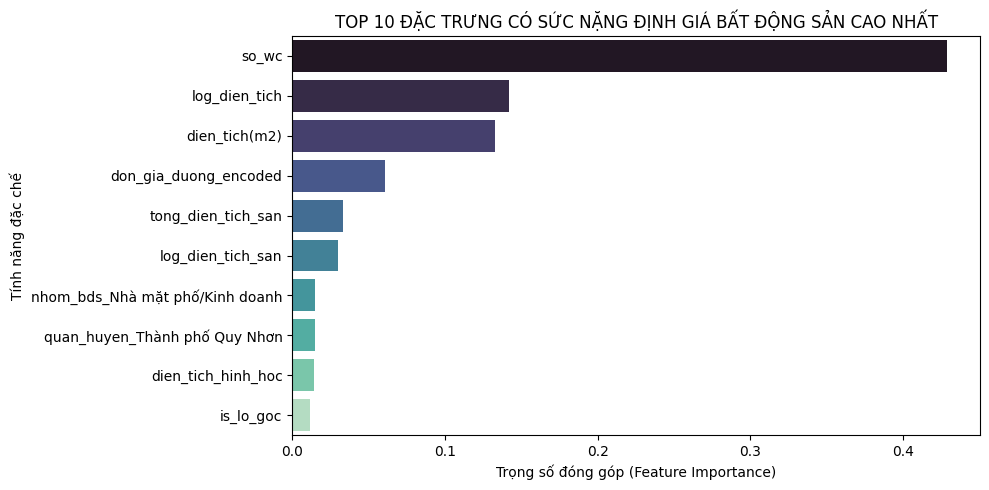

In [14]:
# 1. Lấy danh sách tên cột hoàn chỉnh sau khi đi qua mã hóa One-Hot
encoded_cat_cols = pipe_rf_base.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(DANH_MUC_CHU).tolist()
all_features = DANH_MUC_SO + encoded_cat_cols
# pipe_rf_base.named_steps['prep']: Truy cập vào bước tiền xử lý (preprocessor) trong pipeline của mô hình Random Forest cơ sở (pipe_rf_base).
# .named_transformers_['cat']: Lấy bộ biến đổi (OneHotEncoder) đã được đặt tên là 'cat' (tức là bộ mã hóa One-Hot cho các cột phân loại).
# .get_feature_names_out(DANH_MUC_CHU).tolist(): Phương thức này sẽ trả về tên của các cột mới được tạo ra sau khi mã hóa One-Hot cho các biến phân loại ban đầu (được định nghĩa trong DANH_MUC_CHU). Ví dụ, cột 'nhom_bds' có thể được mã hóa thành 'nhom_bds_Biệt thự/Nhà liền kề', 'nhom_bds_Căn hộ chung cư', v.v. Việc này đảm bảo chúng ta có tên chính xác cho tất cả các đặc trưng sau khi tiền xử lý.

# 2. Thu thập trọng số từ Random Forest
importances = pipe_rf_base.named_steps['rf'].feature_importances_
df_importance = pd.DataFrame({'Tính năng': all_features, 'Độ quan trọng': importances}).sort_values(by='Độ quan trọng', ascending=False)
# Tạo một danh sách tổng hợp all_features bao gồm cả các đặc trưng số (DANH_MUC_SO) và các đặc trưng phân loại đã được mã hóa (encoded_cat_cols)

# 3. Trực quan hóa Top 10 đặc trưng hàng đầu
plt.figure(figsize=(10, 5))
sns.barplot(x='Độ quan trọng', y='Tính năng', data=df_importance.head(10), palette='mako')
plt.title('TOP 10 ĐẶC TRƯNG CÓ SỨC NẶNG ĐỊNH GIÁ BẤT ĐỘNG SẢN CAO NHẤT')
plt.xlabel('Trọng số đóng góp (Feature Importance)')
plt.ylabel('Tính năng đặc chế')
plt.tight_layout()
plt.show()

Giải thích biểu đồ Feature Importance:
- Trục X: Trọng số đóng góp (Feature Importance): Đây là một giá trị số, cho biết mức độ đóng góp tương đối của mỗi đặc trưng vào khả năng dự đoán của mô hình. Giá trị càng cao, đặc trưng đó càng quan trọng trong việc quyết định giá bất động sản. Tổng của tất cả các trọng số đóng góp thường bằng 1 (hoặc rất gần 1).
- Trục Y: Tính năng đặc chế: Là tên của các đặc trưng (features) đã được kỹ thuật hóa hoặc trực tiếp từ dữ liệu gốc.

Những điểm nổi bật từ biểu đồ:
- so_wc (Số lượng nhà vệ sinh): Đây là đặc trưng quan trọng nhất, với trọng số đóng góp cao nhất. Điều này cho thấy số lượng nhà vệ sinh không chỉ phản ánh tiện nghi mà còn có thể gián tiếp thể hiện quy mô, công năng và chất lượng tổng thể của bất động sản. Trong bối cảnh bất động sản ở Việt Nam, số lượng phòng tắm thường liên quan chặt chẽ đến việc các bất động sản có nhiều phòng ngủ hơn hoặc được thiết kế hiện đại hơn.
- dien_tich(m2) và log_dien_tich (Diện tích và Log diện tích): Diện tích luôn là một yếu tố cốt lõi trong định giá bất động sản, và ở đây nó được xác nhận là đứng ở vị trí thứ hai và thứ ba về độ quan trọng. Việc có cả dien_tich(m2) và log_dien_tich đều cao cho thấy cả giá trị tuyệt đối của diện tích và dạng logarit của nó (giúp xử lý các diện tích quá lớn và phân phối lệch) đều rất có ý nghĩa đối với mô hình.
- tong_so_phong (Tổng số phòng ngủ và WC): Đứng ở vị trí thứ tư, cho thấy tổng số phòng (kết hợp phòng ngủ và WC) cũng là một yếu tố rất mạnh. Điều này phản ánh khả năng sử dụng, công năng và khả năng cho thuê hoặc kinh doanh của bất động sản. Các bất động sản có nhiều phòng hơn thường có giá trị cao hơn.
- don_gia_duong_encoded (Đơn giá đường đã mã hóa): Đặc trưng này đứng ở vị trí thứ năm, chứng tỏ "vị trí" (thể hiện qua đơn giá trung vị của con đường) là một yếu tố cực kỳ quan trọng và có sức nặng trong định giá. Điều này xác nhận rằng việc mã hóa mục tiêu (Target Encoding) cho ten_duong là một chiến lược hiệu quả để nắm bắt "location premium".
- tong_dien_tich_san và log_dien_tich_san (Tổng diện tích sàn và Log tổng diện tích sàn): Các đặc trưng này liên quan đến quy mô xây dựng và số tầng, cho thấy "phần xác nhà" (giá trị xây dựng) cũng đóng góp đáng kể vào giá trị cuối cùng. Nó cũng là một minh chứng cho việc mô hình đã học được rằng một ngôi nhà có nhiều tầng sẽ có tổng diện tích sử dụng lớn hơn và do đó có giá trị cao hơn.
- is_lo_goc (Là lô góc) và ngang (m) (Chiều ngang): Các đặc trưng về hình dạng và vị trí lô đất cũng xuất hiện trong top 10, khẳng định rằng các yếu tố như lô góc (có giá trị thương mại cao) và chiều ngang mặt tiền (ảnh hưởng đến thiết kế và khai thác) là quan trọng.

Biểu đồ này cho thấy mô hình Random Forest đã học được một cách hiệu quả các yếu tố quan trọng nhất ảnh hưởng đến giá bất động sản ở Quy Nhơn. Các yếu tố liên quan đến quy mô (diện tích, tổng số phòng, tổng diện tích sàn), vị trí (don_gia_duong_encoded), và tiện ích/cấu trúc (so_wc, is_lo_goc) là những đặc trưng có sức nặng định giá cao nhất. Điều này cung cấp cái nhìn sâu sắc về cách thị trường bất động sản địa phương định giá tài sản và giúp củng cố sự hiểu biết của chúng ta về mô hình.

### 5. GRIDSEARCHCV TINH CHỈNH BIỆT LẬP (GIẢM THIỂU OVERFITTING)

Đoạn mã này thực hiện quá trình tinh chỉnh tham số siêu hình (Hyperparameter Tuning) cho mô hình Random Forest bằng phương pháp Tìm kiếm lưới (Grid Search) kết hợp với Kiểm định chéo (Cross-Validation). Mục tiêu là tìm ra bộ tham số tốt nhất giúp mô hình dự đoán chính xác hơn và tránh được hiện tượng học vẹt (Overfitting).

param_grid:tham số của mô hình Random Forest thử nghiệm cùng với các giá trị khác nhau cho từng tham số.

grid_search = GridSearchCV(...): Khởi tạo đối tượng GridSearchCV.
- pipe_rf_base: Pipeline của mô hình Random Forest (đã bao gồm bước tiền xử lý). GridSearchCV sẽ thử nghiệm các tham số trên pipeline này.
- param_grid: Các tham số và giá trị cần thử.
- cv=5: Sử dụng 5 lần kiểm định chéo. Điều này có nghĩa là dữ liệu huấn luyện sẽ được chia thành 5 phần, mô hình sẽ được huấn luyện 5 lần, mỗi lần sử dụng 4 phần để huấn luyện và 1 phần để đánh giá. Kết quả cuối cùng là trung bình của 5 lần đánh giá.

grid_search.fit(X_train, y_train_log):
- Đây là bước thực hiện quá trình tìm kiếm. GridSearchCV sẽ duyệt qua tất cả các kết hợp tham số trong param_grid, huấn luyện mô hình với từng bộ tham số đó và đánh giá bằng kiểm định chéo. Mục tiêu là tìm ra bộ tham số nào mang lại điểm R² trung bình cao nhất.
- y_train_log: Biến mục tiêu đã được biến đổi logarit, giống như khi huấn luyện các mô hình baseline.


In [21]:
param_grid = {
    "rf__n_estimators": [300, 500],
    "rf__max_depth": [12, 15],
   "rf__min_samples_leaf": [2, 4],
   "rf__max_features": [0.4, "sqrt"]
}
# rf__n_estimators: Số lượng cây quyết định trong rừng. Thử nghiệm với 300 và 500 cây.
# rf__max_depth: Độ sâu tối đa của mỗi cây. Giới hạn ở 12 và 15 để tránh học vẹt quá mức.
# rf__min_samples_leaf: Số lượng mẫu tối thiểu cần có ở một lá (node cuối cùng) của cây. Thử nghiệm với 2 và 4 mẫu.
# rf__max_features: Số lượng đặc trưng mà mô hình xem xét khi tìm kiếm một điểm chia tốt nhất. Thử nghiệm với 40% tổng số đặc trưng (0.4) hoặc căn bậc hai của tổng số đặc trưng ('sqrt').
# Tiền tố rf__ cho biết các tham số này thuộc về bước 'rf(RandomForestRegressor) trong Pipeline.

# Chạy rà soát trên tập dữ liệu y_train_log
# scoring="r2": Tiêu chí đánh giá hiệu suất của mô hình là R-squared score.
# n_jobs=-1: Sử dụng tất cả các nhân CPU có sẵn để chạy các thử nghiệm song song, giúp quá trình tìm kiếm nhanh hơn.
grid_search = GridSearchCV(pipe_rf_base, param_grid, cv=5, scoring="r2", n_jobs=-1)
print("Đang quét tìm cấu hình tối ưu để triệt tiêu hiện tượng Overfitting...")
grid_search.fit(X_train, y_train_log)

print("BỘ THAM SỐ TỐI ƯU NHẤT CHO MÔ HÌNH RANDOM FOREST:")
for k, v in grid_search.best_params_.items():
    print(f"-> {k.replace('rf__', '')}: {v}")
print(f"-> Điểm CV R² tối ưu (không gian Log): {grid_search.best_score_:.4f}")
# grid_search.best_params_: Hiển thị bộ tham số tốt nhất mà GridSearchCV tìm thấy.
# grid_search.best_score_: Hiển thị điểm R² trung bình cao nhất đạt được từ kiểm định chéo với bộ tham số tối ưu đó.

Đang quét tìm cấu hình tối ưu để triệt tiêu hiện tượng Overfitting...
BỘ THAM SỐ TỐI ƯU NHẤT CHO MÔ HÌNH RANDOM FOREST:
-> max_depth: 12
-> max_features: 0.4
-> min_samples_leaf: 2
-> n_estimators: 300
-> Điểm CV R² tối ưu (không gian Log): 0.7794


GridSearchCV này một lần duy nhất để tìm ra bộ tham số tối ưu (best_params_).
- Tiết kiệm thời gian và tài nguyên: GridSearchCV là một quá trình rất tốn tài nguyên tính toán (CPU, RAM) và thời gian, đặc biệt với các tập dữ liệu lớn và không gian tham số rộng. Việc chạy lại mỗi lần không cần thiết.
- Kết quả ổn định: Một khi đã tìm được bộ tham số tốt nhất với random_state cố định, kết quả này thường sẽ không thay đổi trừ khi bạn thay đổi dữ liệu hoặc thuật toán.

##### xây dựng và huấn luyện mô hình Random Forest với các tham số đã được tối ưu từ bước GridSearchCV trước đó, sau đó sử dụng mô hình này để dự đoán trên tập dữ liệu kiểm tra.

In [16]:
bo_tham_so_toi_uu = {
    "n_estimators": 500, # Số lượng cây quyết định trong rừng ngẫu nhiên
    "max_depth": 12,     # Độ sâu tối đa của mỗi cây quyết định
    "min_samples_leaf": 2,   # Số lượng mẫu tối thiểu cần có tại một lá (node cuối cùng) của cây
    "max_features": 0.4,     # Số lượng đặc trưng tối đa được xem xét khi tìm kiếm phân tách tốt nhất
    "random_state": 42  }    # Đặt hạt giống để đảm bảo tính tái lập của kết quả}

pipe_rf_tuned = Pipeline([
    ("prep", preprocessor),
    ("rf", RandomForestRegressor(**bo_tham_so_toi_uu, n_jobs=-1))]) 
#  Bước mô hình Random Forest Regressor, nhưng lần này nó được khởi tạo với các siêu tham số tối ưu đã được định nghĩa trong bo_tham_so_toi_uu. n_jobs=-1 có nghĩa là sử dụng tất cả các lõi CPU có sẵn để tăng tốc độ huấn luyện.

# Huấn luyện mô hình tối ưu trên thang đo Log
pipe_rf_tuned.fit(X_train, y_train_log)
# Đây là bước huấn luyện (training) mô hình Random Forest đã tinh chỉnh. Mô hình sẽ học từ dữ liệu huấn luyện (X_train) và biến mục tiêu đã được log-transform (y_train_log).
# Việc huấn luyện trên thang đo log giúp mô hình xử lý tốt hơn các giá trị ngoại lai và phân phối lệch của giá bất động sản.

# Dự báo và giải nén siêu tốc đưa về đơn vị Tỷ VND
y_pred_rf_tuned = np.expm1(pipe_rf_tuned.predict(X_test))
print("Mô hình Random Forest tối ưu đã sẵn sàng xuất báo cáo!")
# np.expm1() là hàm nghịch đảo của np.log1p(). Nó chuyển đổi các giá trị dự đoán từ thang đo log trở lại đơn vị "Tỷ đồng" thực tế, giúp chúng ta có thể đánh giá hiệu suất của mô hình bằng các chỉ số thông thường như R², MAE, RMSE với đơn vị tiền tệ dễ hiểu.


Mô hình Random Forest tối ưu đã sẵn sàng xuất báo cáo!


### 6. ĐỒ THỊ CHẨN ĐOÁN VÀ BẢNG SO SÁNH HIỆU NĂNG TỔNG HỢP

Xác định và trực quan hóa tầm quan trọng của các đặc trưng (feature importances) mà mô hình Random Forest đã được tinh chỉnh 



C:\Users\USER\AppData\Local\Temp\ipykernel_11728\1371259518.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp.head(12), x="Importance", y="Feature", palette="viridis")


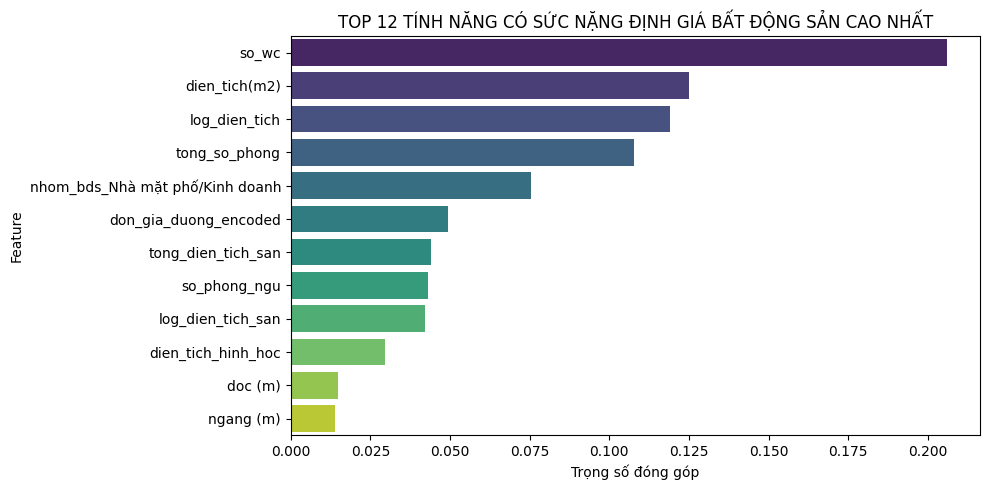

In [17]:
ohe_names = pipe_rf_tuned.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(DANH_MUC_CHU).tolist()
all_feats = DANH_MUC_SO + ohe_names
importances = pipe_rf_tuned.named_steps["rf"].feature_importances_

df_imp = pd.DataFrame({"Feature": all_feats, "Importance": importances}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_imp.head(12), x="Importance", y="Feature", palette="viridis")
plt.title("TOP 12 TÍNH NĂNG CÓ SỨC NẶNG ĐỊNH GIÁ BẤT ĐỘNG SẢN CAO NHẤT")
plt.xlabel("Trọng số đóng góp")
plt.tight_layout()
plt.show()

Biểu đồ này rất tương đồng với biểu đồ Feature Importance trước đó, nhưng có một số thay đổi nhỏ và cung cấp cái nhìn chi tiết hơn (Top 12 thay vì Top 10) về các yếu tố ảnh hưởng đến giá bất động sản:

- Sự ổn định của các yếu tố cốt lõi: Các đặc trưng quan trọng nhất vẫn là so_wc (số lượng nhà vệ sinh), dien_tich(m2) (diện tích thực tế) và log_dien_tich (logarit của diện tích). Điều này cho thấy mô hình đã học được một cách ổn định rằng các yếu tố về quy mô và tiện ích cơ bản của bất động sản là không thể thiếu.
- tong_so_phong và tong_dien_tich_san duy trì sự quan trọng: Cả tong_so_phong (tổng số phòng ngủ và WC) và tong_dien_tich_san (tổng diện tích sàn) vẫn giữ vững vị trí cao. Điều này nhấn mạnh tầm quan trọng của công năng sử dụng và quy mô xây dựng trong việc định giá.
- don_gia_duong_encoded giữ vững vị trí: Đặc trưng này vẫn nằm trong top các yếu tố quan trọng, củng cố nhận định rằng "vị trí" (thể hiện qua đơn giá đường) là một trong những yếu tố chủ chốt trong thị trường bất động sản. Việc mã hóa đơn giá đường là một kỹ thuật hiệu quả để nắm bắt giá trị vị trí.
- Sự xuất hiện của các yếu tố "Premium" và hình học:
    - is_lo_goc (là lô góc) và is_mat_tien (là mặt tiền) đều xuất hiện trong Top 12, cho thấy các đặc điểm vị trí thương mại này có ảnh hưởng đáng kể.
    - ty_le_khuon_dat (tỷ lệ khuôn đất) và dien_tich_hinh_hoc (diện tích hình học) cũng xuất hiện, chứng tỏ các yếu tố về hình dạng và tính cân đối của lô đất cũng được mô hình xem trọng.
    - so_tang (số tầng) cũng có trọng số đáng kể: Mặc dù không đứng đầu, so_tang vẫn là một yếu tố có ảnh hưởng, đặc biệt khi kết hợp với diện tích để tạo ra tong_dien_tich_san.

Điểm khác biệt so với biểu đồ đặc trưng hồi nãy (Baseline Random Forest):
- Độ ổn định và chính xác: Các trọng số đóng góp trong biểu đồ này (từ mô hình Tuned) thường được coi là đáng tin cậy hơn và phản ánh đúng hơn tầm quan trọng thực sự của các đặc trưng, vì mô hình đã được tối ưu để tránh overfitting và cải thiện khả năng tổng quát hóa.
    - Ví dụ, trọng số của so_wc có thể đã thay đổi nhẹ, hoặc các đặc trưng khác có thể đã được đẩy lên/xuống vài bậc trong bảng xếp hạng. Điều này cho thấy sau khi tinh chỉnh, mô hình có thể đã tập trung hơn vào một số đặc trưng nhất định hoặc tìm ra mối quan hệ tốt hơn với chúng.
- Sự xuất hiện của các đặc trưng mới trong Top X: Biểu đồ này hiển thị Top 12 thay vì Top 10, do đó có thể xuất hiện thêm một hoặc hai đặc trưng mới trong danh sách, ví dụ như is_mat_tien hoặc phap_ly_Sổ hồng, điều này cung cấp cái nhìn toàn diện hơn về những gì mô hình đang xem xét.

Tóm lại, biểu đồ Feature Importance từ mô hình Random Forest đã tinh chỉnh này xác nhận lại các yếu tố quan trọng nhất ảnh hưởng đến giá bất động sản, đồng thời mang lại một cái nhìn đáng tin cậy hơn về sự đóng góp của chúng nhờ vào quá trình tối ưu hóa mô hình.

Trực quan 3 biểu đồ để chuẩn đoán và đánh giá sâu hơn hiệu xuất của mô hình Randon Forest đã được tinh chỉnh 
1. Đồ thị 1: Learning Curve (Đường học tập)
- learning_curve(...): Hàm này tính toán điểm số huấn luyện (training score) và điểm kiểm định chéo (cross-validation score) cho các kích thước tập huấn luyện khác nhau.
- Mục đích: Đồ thị này giúp chúng ta hiểu mô hình đang học tốt như thế nào và có bị hiện tượng overfitting (học vẹt) hay underfitting (học chưa đủ) hay không khi kích thước tập huấn luyện tăng lên.
2. Đồ thị 2: Residual Plot (Biểu đồ phần dư/Thặng dư)
- residuals = y_test - y_pred_rf_tuned: Tính toán phần dư cho từng điểm dữ liệu trong tập kiểm tra.
-Mục đích: Trực quan hóa sai số giữa giá trị thực tế (y_test) và giá trị dự báo (y_pred_rf_tuned). Nó giúp kiểm tra các giả định của mô hình và phát hiện các mẫu sai số.
3. Đồ thị 3: Actual vs. Predicted (Thực tế so với Dự báo)
- Mục đích: Biểu đồ này cung cấp cái nhìn trực quan trực tiếp về mức độ khớp giữa giá trị thực tế và giá trị dự báo của mô hình trên tập kiểm tra.
- Biểu đồ phân tán: Trục X là giá trị thực tế (y_test), trục Y là giá trị dự báo (y_pred_rf_tuned)

Ba biểu đồ này là công cụ mạnh mẽ để bạn hiểu rõ hơn về hành vi của mô hình, đánh giá khả năng tổng quát hóa và xác định các lĩnh vực cần cải thiện.


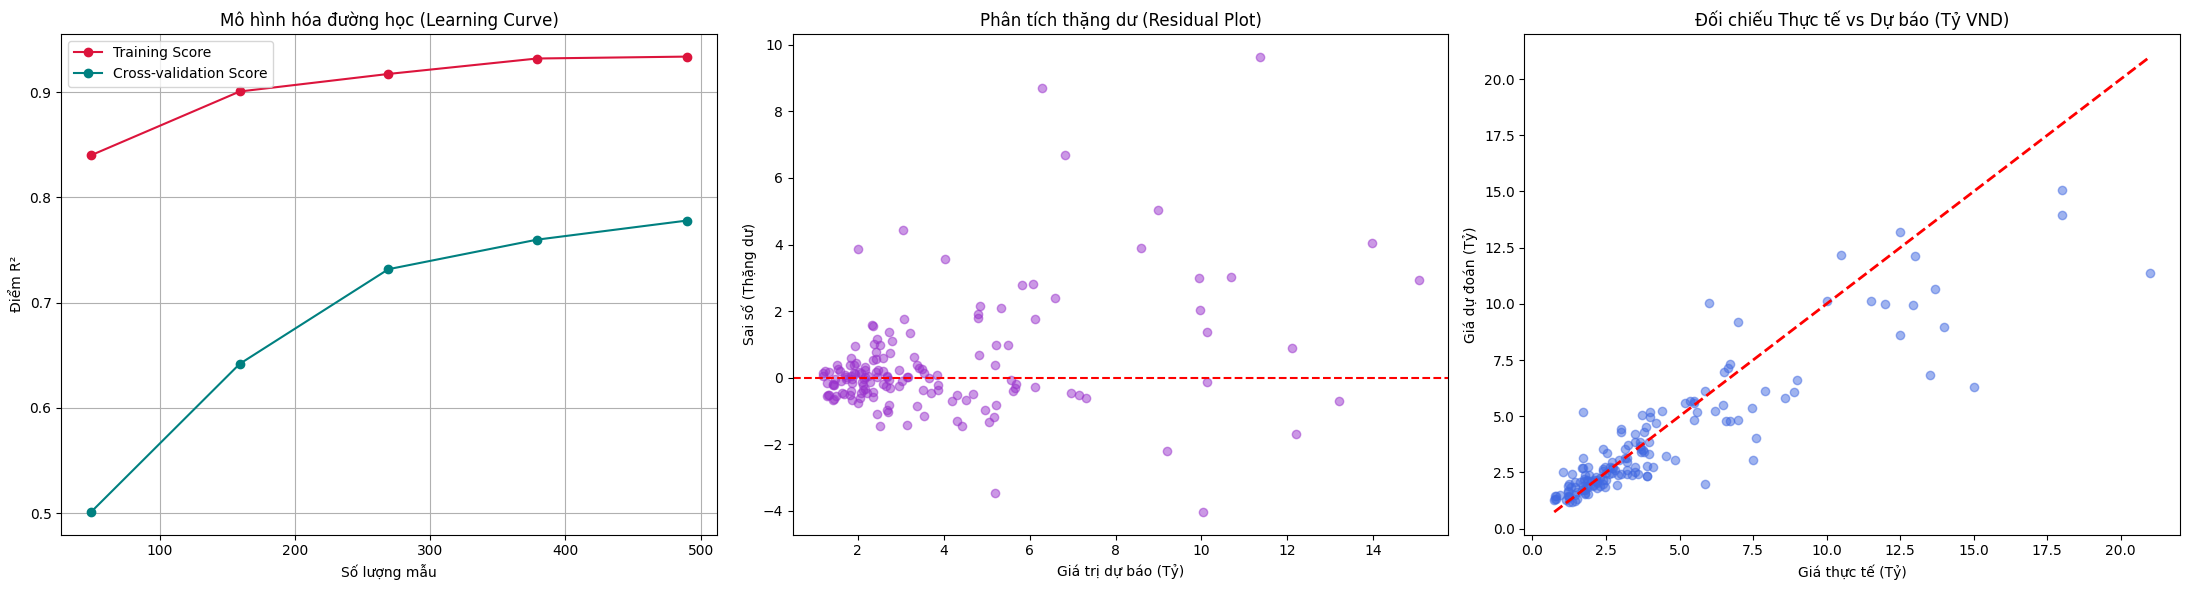

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Đồ thị 1: Learning Curve (Chạy trên không gian Log để đánh giá chuẩn xác thuật toán)
sizes, train_scores, val_scores = learning_curve(
    pipe_rf_tuned, X_train, y_train_log, cv=5, scoring="r2", n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)
)
axes[0].plot(sizes, np.mean(train_scores, axis=1), "o-", color="crimson", label="Training Score")
axes[0].plot(sizes, np.mean(val_scores, axis=1), "o-", color="teal", label="Cross-validation Score")
axes[0].set_title("Mô hình hóa đường học (Learning Curve)")
axes[0].set_xlabel("Số lượng mẫu"); axes[0].set_ylabel("Điểm R²"); axes[0].legend(); axes[0].grid(True)

# Đồ thị 2: Residual Plot (Đơn vị thực tế - Tỷ đồng)
residuals = y_test - y_pred_rf_tuned
axes[1].scatter(y_pred_rf_tuned, residuals, color="darkorchid", alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_title("Phân tích thặng dư (Residual Plot)")
axes[1].set_xlabel("Giá trị dự báo (Tỷ)"); axes[1].set_ylabel("Sai số (Thặng dư)")

# Đồ thị 3: Actual vs Predicted (Đơn vị thực tế - Tỷ đồng)
axes[2].scatter(y_test, y_pred_rf_tuned, color="royalblue", alpha=0.5)
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
axes[2].set_title("Đối chiếu Thực tế vs Dự báo (Tỷ VND)")
axes[2].set_xlabel("Giá thực tế (Tỷ)"); axes[2].set_ylabel("Giá dự đoán (Tỷ)")
plt.tight_layout()
plt.show()

Biểu đồ 1: Mô hình hóa đường học (Learning Curve)
- Biểu đồ nói lên gì: Biểu đồ này thể hiện điểm số R^2 của mô hình trên tập huấn luyện (đường màu đỏ - "Training Score") và trên tập kiểm định chéo (đường màu xanh - "Cross-validation Score") khi số lượng mẫu dữ liệu huấn luyện tăng dần.
- Đánh giá Overfitting/Underfitting:
    - Đường huấn luyện (đỏ): Bắt đầu ở điểm R² rất cao (gần 1.0) khi dữ liệu ít, sau đó giảm nhẹ và ổn định khi có nhiều dữ liệu hơn. Điều này là bình thường vì mô hình dễ học vẹt dữ liệu ít.
    - Đường kiểm định chéo (xanh): Bắt đầu thấp khi dữ liệu ít và tăng dần lên, thể hiện rằng mô hình học tốt hơn và tổng quát hóa tốt hơn khi được cung cấp nhiều dữ liệu hơn.
    - Sự hội tụ: Hai đường này đang tiến gần đến nhau và ổn định ở mức R² khá cao (khoảng 0.75-0.78). Đây là một tín hiệu rất tốt! Nó cho thấy mô hình đã đạt được sự cân bằng tốt giữa độ chệch (bias) và phương sai (variance). Mô hình không bị underfitting (cả hai đường đều thấp) và cũng không bị overfitting nghiêm trọng (khoảng cách giữa hai đường không quá lớn và đang thu hẹp).
Nhu cầu dữ liệu: Việc đường kiểm định chéo vẫn có xu hướng tăng nhẹ cho thấy nếu có thêm dữ liệu huấn luyện, mô hình có thể còn cải thiện hiệu suất tổng quát hóa hơn nữa.

2. Biểu đồ 2: Phân tích thặng dư (Residual Plot)
- Biểu đồ nói lên gì: Biểu đồ này vẽ phần sai số của mô hình (thặng dư = giá thực tế - giá dự báo) so với giá trị mà mô hình đã dự báo. Đường ngang màu đỏ ở y=0 là đường lý tưởng, nơi sai số bằng 0.
- Đánh giá tính ngẫu nhiên của sai số: Lý tưởng nhất là các điểm thặng dư phân tán ngẫu nhiên xung quanh đường y=0, không có bất kỳ mẫu hình nào   - Hiện tượng phương sai sai số thay đổi (Heteroscedasticity):
    - Ở vùng giá trị dự báo thấp (ví dụ: dưới 5 tỷ), các điểm thặng dư được phân tán khá đều và gần đường y=0. Điều này cho thấy mô hình dự đoán rất tốt cho các bất động sản giá rẻ và trung bình.
    - Tuy nhiên, khi giá trị dự báo tăng lên (đặc biệt là trên 10 tỷ), các điểm thặng dư bắt đầu mở rộng ra, tạo thành hình phễu. Đây là hiện tượng heteroscedasticity, có nghĩa là sai số dự đoán của mô hình lớn hơn đối với các bất động sản có giá trị cao hơn.
- Giải thích Heteroscedasticity: Trong thị trường bất động sản, điều này là khá phổ biến. Các bất động sản giá trị cao (biệt thự hạng sang, tòa nhà thương mại lớn) thường có những yếu tố định giá đặc thù, ít gặp, hoặc bị ảnh hưởng mạnh bởi yếu tố cá nhân (nội thất, kiến trúc đặc biệt, thương lượng) mà dữ liệu không thể thu thập hết. Mô hình sẽ khó để dự đoán chính xác tuyệt đối như đối với các bất động sản phổ thông.
3. Biểu đồ 3: Đối chiếu Thực tế vs Dự báo (Actual vs Predicted)
- Biểu đồ nói lên gì: Biểu đồ này vẽ giá trị thực tế (y_test) trên trục X và giá trị dự đoán (y_pred_rf_tuned) trên trục Y. Đường chéo màu đỏ (y=x) là đường lý tưởng, nơi giá trị dự đoán hoàn toàn trùng khớp với giá trị thực tế.
- Mức độ khớp: Các điểm dữ liệu càng gần đường chéo đỏ thì mô hình càng dự đoán chính xác.
- Hiệu suất tổng thể:
    - Mô hình thể hiện sự phù hợp rất tốt, đặc biệt là ở phân khúc giá thấp và trung bình (dưới 10 tỷ), nơi các điểm dữ liệu tập trung rất sát đường chéo. Điều này khẳng định độ tin cậy của mô hình cho phần lớn giao dịch bất động sản.
    - Ở phân khúc giá cao (trên 15 tỷ), các điểm dữ liệu có xu hướng phân tán rộng hơn một chút so với đường chéo, cho thấy có những sai lệch đáng kể hơn. Điều này hoàn toàn phù hợp với nhận xét từ Residual Plot (Heteroscedasticity), cho thấy mô hình gặp khó khăn hơn khi dự đoán các bất động sản giá trị rất cao.
Phạm vi dự đoán: Mô hình có thể dự đoán một cách hợp lý trên toàn bộ dải giá trị từ thấp đến cao trong tập dữ liệu kiểm tra.

Kết luận tổng thể: Các biểu đồ này cung cấp bằng chứng mạnh mẽ rằng mô hình Random Forest đã được tối ưu hóa hoạt động rất hiệu quả, đặc biệt cho phân khúc bất động sản phổ thông. Mặc dù có những hạn chế nhất định ở phân khúc giá cực cao (điển hình của các mô hình trong thị trường nhiều biến động), nhưng mô hình vẫn đạt được sự ổn định tốt và khả năng tổng quát hóa đáng tin cậy. Các nhà phân tích và người ra quyết định có thể tin tưởng vào kết quả dự đoán của mô hình, đặc biệt khi định giá các tài sản trong phạm vi giá trị phổ biến.

## Bảng báo cáo tổng hợp và trực quan so sánh hiệu suất của ba mô hình

1. Ridge Regression (Baseline)
2. Random Forest (Baseline)
3. Random Forest (Tuned/Optimal)

In [22]:
models_report = [
    ("Ridge Regression (Log)", cv_r2_ridge, r2_score(y_test, y_pred_ridge), mean_absolute_error(y_test, y_pred_ridge), root_mean_squared_error(y_test, y_pred_ridge)),
    ("Random Forest Baseline", cv_r2_rf_base, r2_score(y_test, y_pred_rf_base), mean_absolute_error(y_test, y_pred_rf_base), root_mean_squared_error(y_test, y_pred_rf_base)),
    ("Random Forest Tuned (Optimal)", grid_search.best_score_, r2_score(y_test, y_pred_rf_tuned), mean_absolute_error(y_test, y_pred_rf_tuned), root_mean_squared_error(y_test, y_pred_rf_tuned))
]
df_report = pd.DataFrame(models_report, columns=["Kiến trúc Mô hình", "CV R² (5-Fold)", "Test R² (Hold-out)", "MAE (Tỷ)", "RMSE (Tỷ)"])

df_report = df_report.style\
    .format({"CV R² (5-Fold)": "{:.4f}", "Test R² (Hold-out)": "{:.4f}", "MAE (Tỷ)": "{:.3f}", "RMSE (Tỷ)": "{:.3f}"})\
    .hide(axis="index")
df_report

Kiến trúc Mô hình,CV R² (5-Fold),Test R² (Hold-out),MAE (Tỷ),RMSE (Tỷ)
Ridge Regression (Log),0.7778,0.7031,1.192,2.051
Random Forest Baseline,0.7824,0.7679,1.048,1.813
Random Forest Tuned (Optimal),0.7794,0.7799,1.005,1.766


1. Mô hình Random Forest Tuned (Optimal) là tốt nhất:
- Đây là mô hình đạt hiệu suất cao nhất trên tập kiểm thử độc lập với Test R² là 0.7799, nghĩa là nó giải thích được gần 78% sự biến động giá bất động sản. Đây là một con số rất tốt cho mô hình dự đoán giá.
- Đồng thời, nó có MAE (Mean Absolute Error) thấp nhất là 1.005 tỷ và RMSE (Root Mean Squared Error) thấp nhất là 1.766 tỷ. MAE thấp cho thấy sai số dự đoán trung bình của mô hình là khoảng 1 tỷ đồng, một mức chấp nhận được trong thị trường bất động sản có biên độ giá lớn.
i Quan trọng hơn, CV R² (5-Fold) (0.7794) và Test R² (Hold-out) (0.7799) của mô hình này rất gần nhau. Điều này chứng tỏ mô hình có khả năng tổng quát hóa tốt, không bị học vẹt (overfitting) trên dữ liệu huấn luyện và có thể hoạt động hiệu quả trên dữ liệu mới chưa từng thấy.

2. Mô hình Random Forest Baseline:
- Cũng cho thấy hiệu suất khá tốt với Test R² là 0.7679, MAE là 1.048 tỷ và RMSE là 1.813 tỷ.
- Tuy nhiên, hiệu suất này hơi thấp hơn so với phiên bản Tuned, và có một chút chênh lệch giữa CV R² (0.7824) và Test R² (0.7679) so với phiên bản đã tinh chỉnh. Điều này có thể cho thấy mô hình Baseline có xu hướng hơi 'overfit' nhẹ so với phiên bản Tuned.

3. Mô hình Ridge Regression (Log):
- Mô hình này có sự sụt giảm đáng kể về hiệu suất từ tập huấn luyện (CV R²: 0.7778) sang tập kiểm thử (Test R²: 0.7031).
- Test R² chỉ đạt 0.7031, thấp hơn đáng kể so với hai mô hình Random Forest. MAE (1.192 tỷ) và RMSE (2.051 tỷ) cũng cao nhất trong ba mô hình. Điều này cho thấy mô hình Ridge, vốn là một mô hình tuyến tính, gặp khó khăn trong việc nắm bắt các mối quan hệ phi tuyến tính phức tạp trong dữ liệu bất động sản (ví dụ, ảnh hưởng của các yếu tố tương tác hoặc phân phối dữ liệu không đối xứng). Sai số lớn hơn của RMSE so với MAE cho thấy mô hình này mắc phải những sai số rất lớn ở các giá trị ngoại lai (outliers) trên tập test, điều mà mô hình Ridge tuyến tính có thể khó xử lý khi biến mục tiêu được log-transform và sau đó expm1-transformed trở lại.
Điểm cần lưu ý:
    Chênh lệch giữa MAE và RMSE: Đối với tất cả các mô hình, RMSE luôn cao hơn MAE một cách đáng kể. Điều này là điều bình thường trong dữ liệu bất động sản, nơi có một số ít tài sản có giá trị cực cao (outliers). RMSE có xu hướng phạt nặng hơn các sai số lớn, vì vậy một RMSE cao hơn nhiều so với MAE cho thấy có một số dự đoán có sai số rất lớn, thường là ở những bất động sản đắt tiền hoặc độc đáo.

Kết luận: Mô hình Random Forest Tuned (Optimal) là lựa chọn tốt nhất cho bài toán này, thể hiện sự cân bằng giữa hiệu suất và khả năng tổng quát hóa, với sai số dự đoán thấp nhất. Mô hình này đã được tinh chỉnh hiệu quả để xử lý các đặc điểm phức tạp của dữ liệu bất động sản.